In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
mpg = pd.read_csv('auto-mpg.csv')
mpg.shape

(398, 9)

In [3]:
df2 = mpg.copy()
df2.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
df2. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [5]:
df2['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [7]:
df2 = df2[df2.horsepower != '?']
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    object 
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 30.6+ KB


In [8]:
mpg_r = pd.read_csv('auto-mpg.csv', na_values = ['?'])
mpg_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [9]:
df = mpg_r.copy()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.5,126.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


In [10]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [11]:
df.columns = [c.replace(' ', '_') for c in df.columns]
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [16]:
df = df.drop('car_name', axis=1)
df.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137,0.205873
model_year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.455171,-0.581024,0.205873,0.180662,1.000000


In [25]:
X = df.drop(['origin', 'mpg'], axis=1)
y = df['mpg']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((318, 6), (80, 6), (318,), (80,))

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

X_train_s

array([[ 1.51040727,  1.07508267,  1.25238452,  0.54139086, -1.30971783,
        -1.69540513],
       [-0.86227768, -0.93225674, -0.40975295, -1.00783493, -0.40324852,
        -1.69540513],
       [-0.86227768, -0.99044049, -0.94592632, -1.13267661,  0.93832606,
         1.6614434 ],
       ...,
       [-0.86227768, -0.57345694, -0.22209226, -0.55008211, -0.2944722 ,
         0.54249389],
       [-0.86227768, -1.00983508, -1.10677834, -1.1029524 ,  0.61199711,
         1.38170602],
       [-0.86227768, -0.93225674, -1.53571704, -1.22184924,  1.95357168,
        -0.85619299]])

In [28]:
y_train = y_train.values

In [30]:
from tensorflow import keras
from keras import layers

model = keras.Sequential([
    layers.Dense(units=6, activation='relu', input_shape=(6, )),
    layers.Dense(units=3, activation='relu'),
    layers.Dense(units=1)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 6)                   │              42 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │              21 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    loss='mse',
    optimizer='ADAM',
    metrics=['mse', 'mae']
)

In [55]:
EPOCHS = 200
BATCH_SIZE = 16

history = model.fit(
    X_train_s, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=1
)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 466.2351 - mae: 20.0223 - mse: 466.1330 
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 462.9837 - mae: 19.9709 - mse: 463.0842 
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 449.0796 - mae: 19.8208 - mse: 449.0551 
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 490.0916 - mae: 20.5575 - mse: 490.1913 
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 457.9303 - mae: 20.0002 - mse: 458.1087 
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 474.2485 - mae: 20.3595 - mse: 474.3611 
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 488.1597 - mae: 20.5716 - mse: 488.0325 
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 462.1220 - mae: 19.9941 - mse: 462.3248 
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 453.1908 - mae: 19.6962 - mse: 452.9845 
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 470.2827 - mae: 20.0535 - mse: 470.5992 

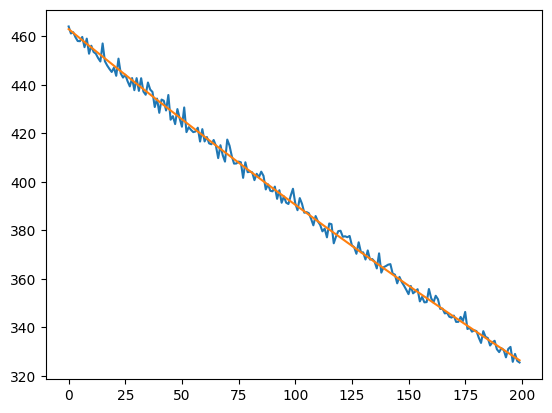

In [56]:
hist = history.history
epoch = history.epoch

plt.plot(epoch, hist['loss'], label='loss')
plt.plot(epoch, hist['mse'], label='mse')
# plt.plot(epoch, hist['mae'], label='mae')
plt.show()

In [57]:
X_test = X_test.dropna()
y_test = y_test[X_test.index]

X_test_s = scaler.transform(X_test)

In [58]:
y_pred = model.predict(X_test_s)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [59]:
y_pred.shape, y_test.shape

((79, 1), (79,))

In [63]:
y_pred = y_pred.reshape(-1)

In [64]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test, y_pred)

307.0320587803787

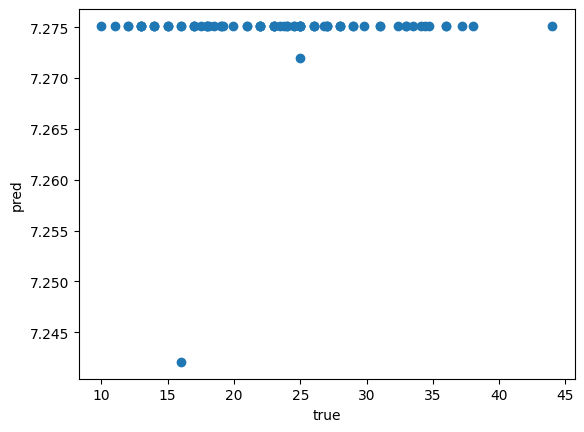

In [65]:
plt.scatter(y_test, y_pred)
plt.xlabel('true')
plt.ylabel('pred')
plt.show()